In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from sklearn.datasets import make_blobs

In [ ]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=3)


In [4]:
y

array([2, 1, 1, 2, 0, 0, 0, 0, 2, 1, 2, 1, 0, 2, 2, 2, 1, 2, 2, 1, 2, 2,
       1, 2, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0, 2, 2, 2, 1, 0, 0, 2, 0, 2, 1,
       0, 0, 1, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 2, 0, 1,
       0, 0, 2, 1, 2, 1, 1, 1, 1, 0, 0, 0, 1, 2, 1, 1, 1, 0, 1, 2, 0, 0,
       2, 1, 1, 2, 1, 2, 1, 1, 0, 1, 0, 2, 0, 0, 1, 2, 0, 2, 1, 1, 2, 1,
       0, 0, 1, 0, 1, 2, 0, 2, 2, 2, 1, 2, 1, 0, 1, 0, 2, 1, 0, 1, 1, 1,
       1, 1, 2, 2, 1, 1, 0, 0, 0, 1, 1, 1, 0, 2, 1, 0, 0, 1, 2, 1, 0, 1,
       2, 1, 0, 2, 2, 0, 1, 1, 2, 1, 0, 0, 0, 0, 2, 0, 1, 1, 0, 2, 2, 2,
       0, 0, 0, 1, 1, 2, 0, 2, 0, 2, 2, 2, 1, 2, 2, 0, 0, 1, 1, 0, 1, 2,
       0, 2, 1, 0, 2, 2, 0, 2, 1, 1, 2, 0, 1, 1, 1, 2, 0, 2, 1, 1, 0, 2,
       1, 0, 0, 1, 1, 2, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 1, 0, 1, 0, 0,
       0, 0, 2, 1, 2, 1, 1, 0, 2, 2, 0, 0, 2, 1, 1, 0, 0, 0, 0, 0, 2, 0,
       2, 0, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 0, 0, 2, 1, 1, 0, 0, 1, 1,
       1, 2, 0, 1, 1, 2, 2, 1, 1, 0, 0, 0, 1, 2, 2,

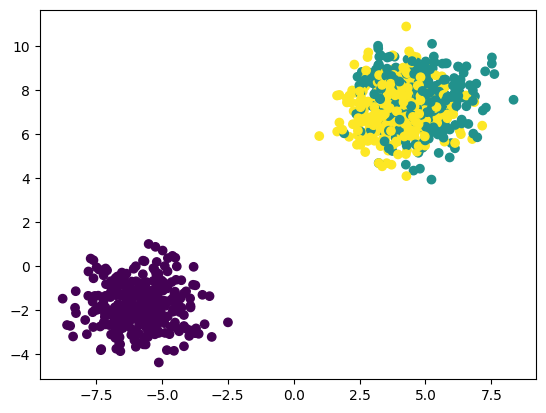

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
## standardization -- feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [8]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans


In [14]:
wccs = []
for i in range(1,15):
    kmeans = KMeans(n_clusters=i,init ='k-means++')
    kmeans.fit(X_train_scaled)
    wccs.append(kmeans.inertia_)


In [15]:
wccs

[2400.000000000001,
 533.6766607742401,
 103.90252910171208,
 91.52814185493726,
 82.81767340983009,
 74.80798895481982,
 67.93179600134839,
 63.11474952121524,
 59.058596990091374,
 53.34392004151056,
 51.54837208275235,
 49.429682932854064,
 46.72992606780838,
 44.57174596741507]

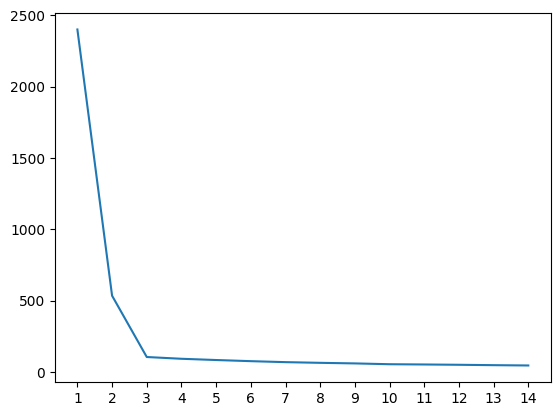

In [19]:
## plot elbow curve
plt.plot(range(1,15),wccs)
plt.xticks(range(1,15))
plt.show()

In [ ]:
## it means for n = 3 we get good clustering i.e elbow point
''' now we can see it is 3 and in mmaking of dataset we also used centre = 3
 implying our our cebtre should be three for KMeans()
'''


In [20]:
kmeans = KMeans(n_clusters=3,init ='k-means++')
kmeans.fit_predict(X_train_scaled)


array([2, 2, 0, 2, 1, 0, 0, 0, 2, 0, 2, 2, 0, 0, 1, 1, 1, 0, 1, 2, 1, 1,
       1, 0, 2, 2, 1, 0, 2, 2, 2, 2, 1, 0, 0, 0, 1, 0, 0, 2, 1, 0, 2, 1,
       1, 2, 2, 0, 2, 2, 2, 1, 0, 1, 2, 1, 2, 1, 2, 0, 0, 2, 2, 1, 0, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 0, 1, 1,
       0, 0, 2, 1, 1, 1, 2, 2, 2, 0, 0, 2, 0, 0, 1, 0, 2, 1, 1, 1, 1, 2,
       1, 0, 1, 1, 2, 2, 0, 2, 2, 2, 1, 0, 0, 0, 2, 1, 1, 2, 0, 2, 2, 2,
       2, 1, 1, 0, 2, 0, 2, 0, 1, 0, 0, 0, 1, 1, 1, 0, 2, 1, 1, 1, 2, 2,
       1, 2, 1, 1, 0, 0, 1, 0, 1, 2, 0, 0, 1, 2, 0, 1, 0, 2, 0, 1, 0, 0,
       2, 2, 0, 0, 0, 1, 1, 1, 2, 1, 2, 2, 1, 2, 1, 0, 2, 1, 2, 0, 1, 1,
       2, 0, 0, 0, 1, 0, 0, 2, 1, 1, 1, 2, 1, 0, 2, 1, 1, 2, 2, 2, 0, 0,
       1, 2, 0, 0, 1, 1, 0, 0, 2, 2, 2, 1, 2, 0, 0, 0, 0, 2, 2, 0, 2, 2,
       2, 2, 1, 0, 2, 0, 0, 2, 1, 1, 2, 2, 2, 2, 0, 0, 0, 0, 2, 0, 0, 1,
       2, 0, 2, 0, 0, 0, 0, 2, 1, 2, 2, 2, 1, 2, 2, 1, 0, 2, 2, 2, 1, 2,
       1, 0, 0, 2, 0, 2, 1, 0, 0, 0, 1, 2, 2, 2, 2,

In [21]:
y_pred = kmeans.predict(X_test_scaled)

## Validation of K-values
1. knee locator
2. silhoute scoring

In [23]:
## knee locator
!pip install kneed

In [29]:
from kneed import KneeLocator
kl = KneeLocator(range(1,15),wccs,curve='convex',direction='decreasing')

In [30]:
kl.elbow

np.int64(3)

In [31]:
## shiloue scoring
from sklearn.metrics import silhouette_score


In [46]:
shiloute_coff = []
for k in range(2,15):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    shiloute_coff.append(score)
    

In [43]:
shiloute_coff

[]

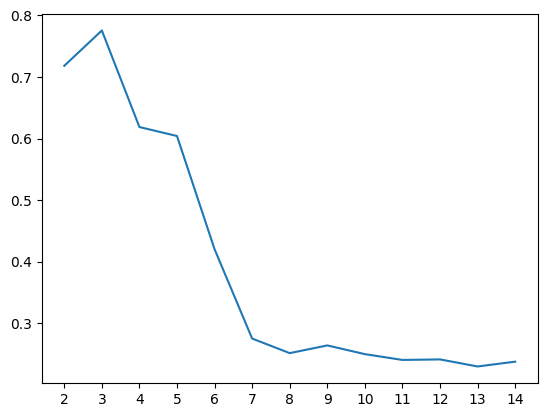

In [47]:
plt.plot(range(2,15),shiloute_coff)
plt.xticks(range(2,15))
plt.show()